In [ ]:
import numpy as np
from collections import deque

class CustomDBSCAN:
    def __init__(self, eps=0.5, min_pts=5):
        """
        Initialize DBSCAN parameters.
        :param eps: Maximum distance between two points to be considered neighbors.
        :param min_pts: Minimum number of points to form a dense region.
        """
        self.eps = eps
        self.min_pts = min_pts
        self.labels_ = None  # Cluster labels (-1 for noise)

    def fit_predict(self, X):
        """
        Run DBSCAN clustering on input data.
        :param X: Input data (numpy array of shape [n_samples, n_features]).
        :return: Cluster labels for each point.
        """
        n_samples = X.shape[0]
        self.labels_ = np.full(n_samples, -1)  # Initialize all points as noise (-1)
        cluster_id = 0

        # Helper function to find neighbors within epsilon distance
        def get_neighbors(point_idx):
            distances = np.linalg.norm(X - X[point_idx], axis=1)
            return np.where(distances <= self.eps)[0]

        # Iterate over all points
        for point_idx in range(n_samples):
            if self.labels_[point_idx] != -1:  # Skip already processed points
                continue

            # Find neighbors of the current point
            neighbors = get_neighbors(point_idx)

            if len(neighbors) < self.min_pts:
                # Not enough neighbors, mark as noise (for now)
                self.labels_[point_idx] = -1
                continue

            # Start a new cluster
            cluster_id += 1
            self.labels_[point_idx] = cluster_id

            # Expand the cluster using a queue
            queue = deque(neighbors)
            while queue:
                neighbor_idx = queue.popleft()

                if self.labels_[neighbor_idx] == -1:  # Previously labeled as noise
                    self.labels_[neighbor_idx] = cluster_id

                if self.labels_[neighbor_idx] != -1:  # Already processed
                    continue

                # Add this point to the cluster
                self.labels_[neighbor_idx] = cluster_id

                # Find neighbors of this point
                neighbor_neighbors = get_neighbors(neighbor_idx)
                if len(neighbor_neighbors) >= self.min_pts:
                    queue.extend(neighbor_neighbors)

        return self.labels_

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import umap.umap_ as umap
from sklearn.utils import shuffle
from sklearn.cluster import DBSCAN as SklearnDBSCAN

# Load and preprocess the 20 Newsgroups dataset
def load_20newsgroups(n_samples=2000):
    print("Loading 20 Newsgroups dataset...")

    # Load the dataset with categories
    categories = ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware',
                  'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles',
                  'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med',
                  'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast',
                  'talk.politics.misc', 'talk.religion.misc']

    data = fetch_20newsgroups(subset='all', categories=categories, shuffle=True, random_state=42)

    # Limit to n_samples
    if n_samples < len(data.data):
        data.data = data.data[:n_samples]
        data.target = data.target[:n_samples]

    # Extract TF-IDF features
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(data.data)

    # Dimensionality reduction with TruncatedSVD
    svd = TruncatedSVD(n_components=100, random_state=42)
    X_reduced = svd.fit_transform(X)

    # Standardize features
    X_reduced = StandardScaler().fit_transform(X_reduced)

    # Further reduce dimensions with UMAP for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_reduced)

    return X_reduced, data.target, X_umap

# Load and preprocess the MNIST dataset
def load_mnist(n_samples=5000):
    print("Loading MNIST dataset...")

    # Load MNIST dataset
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Combine train and test data
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])

    # Shuffle and sample
    X, y = shuffle(X, y, random_state=42)
    X, y = X[:n_samples], y[:n_samples]

    # Reshape and normalize
    X = X.reshape(X.shape[0], -1) / 255.0

    # Use UMAP for dimensionality reduction
    print("Reducing dimensions with UMAP...")
    X_reduced = umap.UMAP(n_components=50, random_state=42).fit_transform(X)

    # Further reduce to 2D for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_reduced)

    return X_reduced, y, X_umap

# Load and preprocess the Fashion MNIST dataset
def load_fashion_mnist(n_samples=5000):
    print("Loading Fashion MNIST dataset...")

    # Load Fashion MNIST dataset
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

    # Combine train and test data
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])

    # Shuffle and sample
    X, y = shuffle(X, y, random_state=42)
    X, y = X[:n_samples], y[:n_samples]

    # Reshape and normalize
    X = X.reshape(X.shape[0], -1) / 255.0

    # Use UMAP for dimensionality reduction
    X_reduced = umap.UMAP(n_components=50, random_state=42).fit_transform(X)

    # Further reduce to 2D for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_reduced)

    return X_reduced, y, X_umap

# Load and preprocess Household Power Consumption dataset
def load_household(n_samples=5000):
    print("Loading Household Power Consumption dataset...")

    # Define CSV file path
    file_path = 'household_power_consumption.txt'

    # Check if file exists, otherwise download it
    if not os.path.exists(file_path):
        print("Dataset not found. Please download it from UCI repository first.")
        # You could add automatic download here
        return None, None, None

    # Load data with appropriate settings
    df = pd.read_csv(file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
                     dayfirst=True, low_memory=False, na_values=['?'])

    # Handle missing values
    df.dropna(inplace=True)

    # Extract features
    X = df[['Global_active_power', 'Global_reactive_power', 'Voltage',
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].values

    # Shuffle and sample
    if n_samples < len(X):
        X = shuffle(X, random_state=42)[:n_samples]

    # Standardize
    X = StandardScaler().fit_transform(X)

    # Create a simple target based on power consumption (for evaluation only)
    # This is artificial since it's unsupervised learning
    y = np.zeros(X.shape[0])
    y[X[:, 0] > 1.0] = 1  # High power consumption
    y[X[:, 0] > 3.0] = 2  # Very high power consumption

    # Reduce dimensions for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X)

    return X, y, X_umap

# Evaluate clustering results
def evaluate_clustering(X, labels, true_labels=None, dataset_name=''):
    """
    Evaluate clustering results using various metrics
    """
    # Count clusters and noise points
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_percentage = n_noise / len(labels) * 100

    print(f"\nEvaluation for {dataset_name} dataset:")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise} ({noise_percentage:.2f}%)")

    if n_clusters > 0:
        # Calculate silhouette score if more than one cluster
        if n_clusters > 1:
            # Use only non-noise points for silhouette
            mask = labels != -1
            if np.sum(mask) > n_clusters:
                try:
                    sil_score = silhouette_score(X[mask], labels[mask])
                    print(f"Silhouette Score: {sil_score:.4f}")
                except:
                    print("Silhouette Score could not be computed (too many samples or memory error)")

    # If true labels are available, calculate external metrics
    if true_labels is not None:
        # Calculate ARI and NMI
        ari = adjusted_rand_score(true_labels, labels)
        nmi = normalized_mutual_info_score(true_labels, labels)

        print(f"Adjusted Rand Index: {ari:.4f}")
        print(f"Normalized Mutual Information: {nmi:.4f}")

    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_percentage': noise_percentage
    }

def run_custom_dbscan_on_dataset(X, true_labels, X_umap, dataset_name, epsilon, min_pts):
    print(f"\nRunning Custom DBSCAN on {dataset_name} dataset with epsilon={epsilon}, min_pts={min_pts}")

    # Use custom DBSCAN
    dbscan = CustomDBSCAN(eps=epsilon, min_pts=min_pts)
    labels = dbscan.fit_predict(X)

    # Evaluate clustering
    eval_results = evaluate_clustering(X, labels, true_labels, dataset_name)

    # Visualization
    plt.figure(figsize=(15, 6))

    # Plot ground truth
    plt.subplot(1, 2, 1)
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=true_labels, cmap='tab10', s=5, alpha=0.7)
    plt.title(f'{dataset_name} - Ground Truth')

    # Plot DBSCAN results
    plt.subplot(1, 2, 2)

    # Plot noise points
    noise_mask = labels == -1
    plt.scatter(X_umap[noise_mask, 0], X_umap[noise_mask, 1], c='black', marker='x', s=5, alpha=0.5, label='Noise')

    # Plot clustered points
    non_noise_mask = ~noise_mask
    plt.scatter(X_umap[non_noise_mask, 0], X_umap[non_noise_mask, 1], c=labels[non_noise_mask], cmap='tab10', s=5, alpha=0.7)

    plt.title(f'{dataset_name} - Custom DBSCAN (ε={epsilon}, MinPts={min_pts})')

    plt.tight_layout()
    plt.savefig(f'custom_dbscan_{dataset_name.lower().replace(" ", "_")}.png')
    plt.show()

    return labels, eval_results

In [ ]:
dbscan_params = {
    '20Newsgroups': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
    'MNIST': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
    'FashionMNIST': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
    'Household': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
}

def grid_search_custom_dbscan(X_umap, true_labels, dataset_name, min_pts, eps_range):
    """
    Perform a grid search over epsilon values to find the best DBSCAN parameters.

    :param X_umap: 2D reduced data for clustering (numpy array).
    :param true_labels: Ground truth labels for evaluation (optional, can be None).
    :param dataset_name: Name of the dataset for logging purposes.
    :param min_pts: Minimum number of points to form a dense region.
    :param eps_range: Range of epsilon values to test.
    :return: Best epsilon value and corresponding cluster labels.
    """
    print(f"\n🔍 Grid Search on {dataset_name}")
    best_score = -1
    best_eps = None
    best_labels = None

    for eps in eps_range:
        # Use CustomDBSCAN instead of SklearnDBSCAN
        db = CustomDBSCAN(eps=eps / 10, min_pts=min_pts)
        predicted_labels = db.fit_predict(X_umap)

        # Skip if all points are noise or only one cluster
        unique_labels = set(predicted_labels)
        if len(unique_labels) <= 1 or unique_labels == {-1}:
            print(f"  Epsilon: {eps / 10:.2f} → All points are noise or single cluster. Skipping...")
            continue

        try:
            # Compute Silhouette Score for non-noise points
            mask = predicted_labels != -1
            if np.sum(mask) > 1:  # Ensure there are enough points for Silhouette Score
                sil_score = silhouette_score(X_umap[mask], predicted_labels[mask])
                print(f"  Epsilon: {eps / 10:.2f} → Silhouette Score: {sil_score:.4f}")
                if sil_score > best_score:
                    best_score = sil_score
                    best_eps = eps / 10
                    best_labels = predicted_labels
            else:
                print(f"  Epsilon: {eps / 10:.2f} → Not enough points for Silhouette Score. Skipping...")
        except Exception as e:
            print(f"  Epsilon: {eps / 10:.2f} → Error in silhouette score: {e}")
            continue

    if best_eps is not None:
        print(f"✅ Best epsilon for {dataset_name}: {best_eps:.2f} with Silhouette Score: {best_score:.4f}")
        return best_eps, best_labels
    else:
        print(f"⚠ No suitable clustering found for {dataset_name}")
        return None, None

# Modify your original run code to include grid search
# Process and run DBSCAN on 20 Newsgroups
X_20ng, y_20ng, X_umap_20ng = load_20newsgroups(n_samples=2000)
best_eps_20ng, best_labels_20ng = grid_search_custom_dbscan(X_umap_20ng, y_20ng, '20Newsgroups',
                                                     min_pts=dbscan_params['20Newsgroups']['min_pts'],
                                                     eps_range=dbscan_params['20Newsgroups']['eps_range'])

# Process and run DBSCAN on MNIST
X_mnist, y_mnist, X_umap_mnist = load_mnist(n_samples=5000)
best_eps_mnist, best_labels_mnist = grid_search_custom_dbscan(X_umap_mnist, y_mnist, 'MNIST',
                                                       min_pts=dbscan_params['MNIST']['min_pts'],
                                                       eps_range=dbscan_params['MNIST']['eps_range'])

# Process and run DBSCAN on Fashion MNIST
X_fmnist, y_fmnist, X_umap_fmnist = load_fashion_mnist(n_samples=5000)
best_eps_fmnist, best_labels_fmnist = grid_search_custom_dbscan(X_umap_fmnist, y_fmnist, 'FashionMNIST',
                                                         min_pts=dbscan_params['FashionMNIST']['min_pts'],
                                                         eps_range=dbscan_params['FashionMNIST']['eps_range'])

# Process and run DBSCAN on Household dataset
X_household, y_household, X_umap_household = load_household(n_samples=5000)
best_eps_household, best_labels_household = grid_search_custom_dbscan(X_umap_household, y_household, 'Household',
                                                                    min_pts=dbscan_params['Household']['min_pts'],
                                                                    eps_range=dbscan_params['Household']['eps_range'])

Loading 20 Newsgroups dataset...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



🔍 Grid Search on 20Newsgroups
  Epsilon: 0.10 → Silhouette Score: 0.5389
  Epsilon: 0.20 → Silhouette Score: 0.3843
  Epsilon: 0.30 → Silhouette Score: 0.3659
  Epsilon: 0.40 → Silhouette Score: 0.2970
  Epsilon: 0.50 → Silhouette Score: 0.3139
  Epsilon: 0.60 → Silhouette Score: 0.2701
  Epsilon: 0.70 → Silhouette Score: 0.2580
  Epsilon: 0.80 → Silhouette Score: 0.2922
  Epsilon: 0.90 → Silhouette Score: 0.2132
  Epsilon: 1.00 → Silhouette Score: 0.2297
  Epsilon: 1.10 → Silhouette Score: 0.1573
  Epsilon: 1.20 → Silhouette Score: 0.1330
  Epsilon: 1.30 → Silhouette Score: 0.1452
  Epsilon: 1.40 → Silhouette Score: 0.1581
  Epsilon: 1.50 → Silhouette Score: 0.1665
  Epsilon: 1.60 → Silhouette Score: 0.2410
  Epsilon: 1.70 → Silhouette Score: 0.1740
  Epsilon: 1.80 → Silhouette Score: 0.1052
  Epsilon: 1.90 → Silhouette Score: 0.2097
  Epsilon: 2.00 → Silhouette Score: 0.1657
  Epsilon: 2.10 → Silhouette Score: 0.1278
  Epsilon: 2.20 → Silhouette Score: 0.1015
  Epsilon: 2.30 → Silho

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



🔍 Grid Search on MNIST
  Epsilon: 0.10 → Silhouette Score: 0.4917
  Epsilon: 0.20 → Silhouette Score: 0.4347
  Epsilon: 0.30 → Silhouette Score: 0.4119
  Epsilon: 0.40 → Silhouette Score: 0.4181
  Epsilon: 0.50 → Silhouette Score: 0.3863
  Epsilon: 0.60 → Silhouette Score: 0.3823
  Epsilon: 0.70 → Silhouette Score: 0.3376
  Epsilon: 0.80 → Silhouette Score: 0.3569
  Epsilon: 0.90 → Silhouette Score: 0.3122
  Epsilon: 1.00 → Silhouette Score: 0.2439
  Epsilon: 1.10 → Silhouette Score: 0.3033
  Epsilon: 1.20 → Silhouette Score: 0.3013
  Epsilon: 1.30 → Silhouette Score: 0.2918
  Epsilon: 1.40 → Silhouette Score: 0.3047
  Epsilon: 1.50 → Silhouette Score: 0.2664
  Epsilon: 1.60 → Silhouette Score: 0.2772
  Epsilon: 1.70 → Silhouette Score: 0.2816
  Epsilon: 1.80 → Silhouette Score: 0.3165
  Epsilon: 1.90 → Silhouette Score: 0.2701
  Epsilon: 2.00 → Silhouette Score: 0.3045
  Epsilon: 2.10 → Silhouette Score: 0.3286
  Epsilon: 2.20 → Silhouette Score: 0.3343
  Epsilon: 2.30 → Silhouette S

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



🔍 Grid Search on FashionMNIST
  Epsilon: 0.10 → Silhouette Score: 0.5048
  Epsilon: 0.20 → Silhouette Score: 0.4545
  Epsilon: 0.30 → Silhouette Score: 0.4574
  Epsilon: 0.40 → Silhouette Score: 0.4210
  Epsilon: 0.50 → Silhouette Score: 0.4256
  Epsilon: 0.60 → Silhouette Score: 0.4018
  Epsilon: 0.70 → Silhouette Score: 0.3945
  Epsilon: 0.80 → Silhouette Score: 0.4110
  Epsilon: 0.90 → Silhouette Score: 0.3965
  Epsilon: 1.00 → Silhouette Score: 0.4007
  Epsilon: 1.10 → Silhouette Score: 0.3685
  Epsilon: 1.20 → Silhouette Score: 0.3963
  Epsilon: 1.30 → Silhouette Score: 0.3670
  Epsilon: 1.40 → Silhouette Score: 0.3681
  Epsilon: 1.50 → Silhouette Score: 0.3596
  Epsilon: 1.60 → Silhouette Score: 0.3612
  Epsilon: 1.70 → Silhouette Score: 0.3559
  Epsilon: 1.80 → Silhouette Score: 0.3284
  Epsilon: 1.90 → Silhouette Score: 0.3376
  Epsilon: 2.00 → Silhouette Score: 0.3329
  Epsilon: 2.10 → Silhouette Score: 0.3205
  Epsilon: 2.20 → Silhouette Score: 0.2958
  Epsilon: 2.30 → Silho

<ipython-input-4-8712d4e16d8e>:116: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



🔍 Grid Search on Household
  Epsilon: 0.10 → Silhouette Score: 0.4494
  Epsilon: 0.20 → Silhouette Score: 0.3477
  Epsilon: 0.30 → Silhouette Score: 0.3080
  Epsilon: 0.40 → Silhouette Score: 0.2821
  Epsilon: 0.50 → Silhouette Score: 0.3035
  Epsilon: 0.60 → Silhouette Score: 0.2781
  Epsilon: 0.70 → Silhouette Score: 0.2481
  Epsilon: 0.80 → Silhouette Score: 0.2681
  Epsilon: 0.90 → Silhouette Score: 0.2967
  Epsilon: 1.00 → Silhouette Score: 0.2779
  Epsilon: 1.10 → Silhouette Score: 0.2496
  Epsilon: 1.20 → Silhouette Score: 0.2440
  Epsilon: 1.30 → Silhouette Score: 0.2156
  Epsilon: 1.40 → Silhouette Score: 0.1640
  Epsilon: 1.50 → Silhouette Score: 0.1724
  Epsilon: 1.60 → Silhouette Score: 0.1791
  Epsilon: 1.70 → Silhouette Score: 0.1891
  Epsilon: 1.80 → Silhouette Score: 0.2876
  Epsilon: 1.90 → Silhouette Score: 0.2860
  Epsilon: 2.00 → Silhouette Score: 0.3218
  Epsilon: 2.10 → Silhouette Score: 0.3069
  Epsilon: 2.20 → Silhouette Score: 0.2941
  Epsilon: 2.30 → Silhouet

Loading 20 Newsgroups dataset...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running Custom DBSCAN on 20Newsgroups dataset with epsilon=3.7, min_pts=5

Evaluation for 20Newsgroups dataset:
Number of clusters: 0
Number of noise points: 2000 (100.00%)
Adjusted Rand Index: 0.0000
Normalized Mutual Information: 0.0000


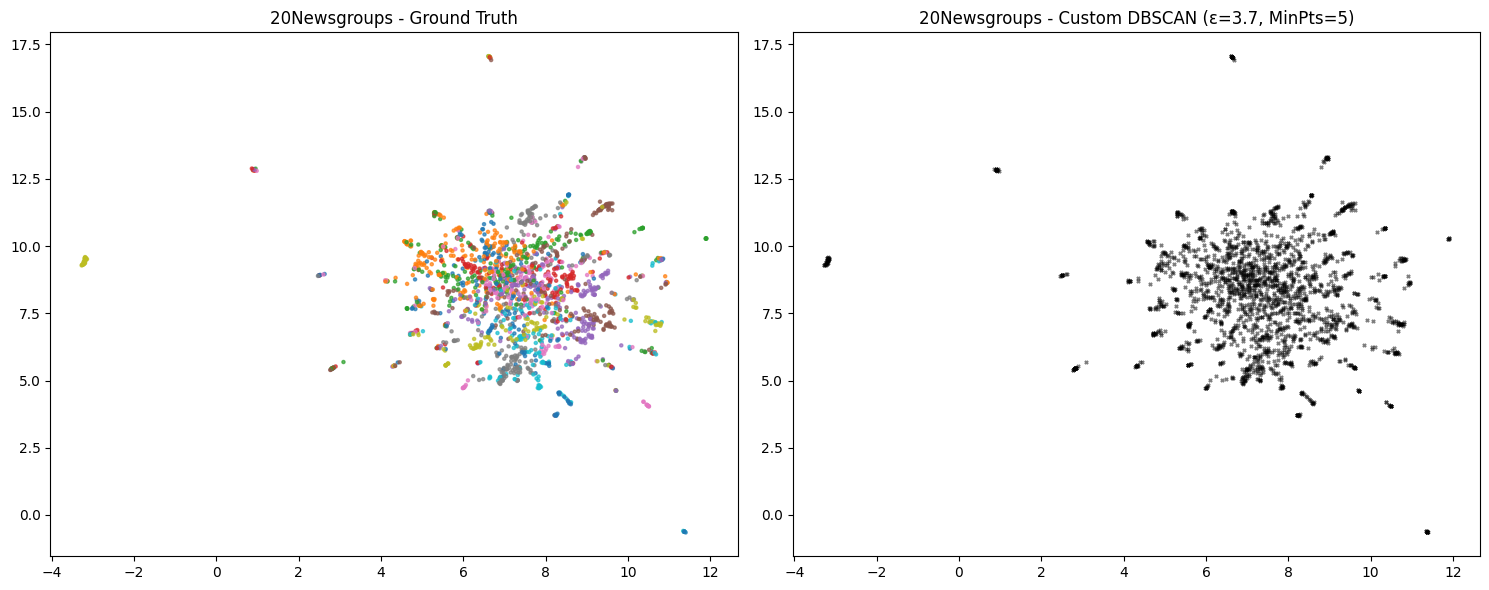

Loading MNIST dataset...
Reducing dimensions with UMAP...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running Custom DBSCAN on MNIST dataset with epsilon=1.3, min_pts=5

Evaluation for MNIST dataset:
Number of clusters: 33
Number of noise points: 0 (0.00%)
Silhouette Score: 0.2017
Adjusted Rand Index: 0.5069
Normalized Mutual Information: 0.6887


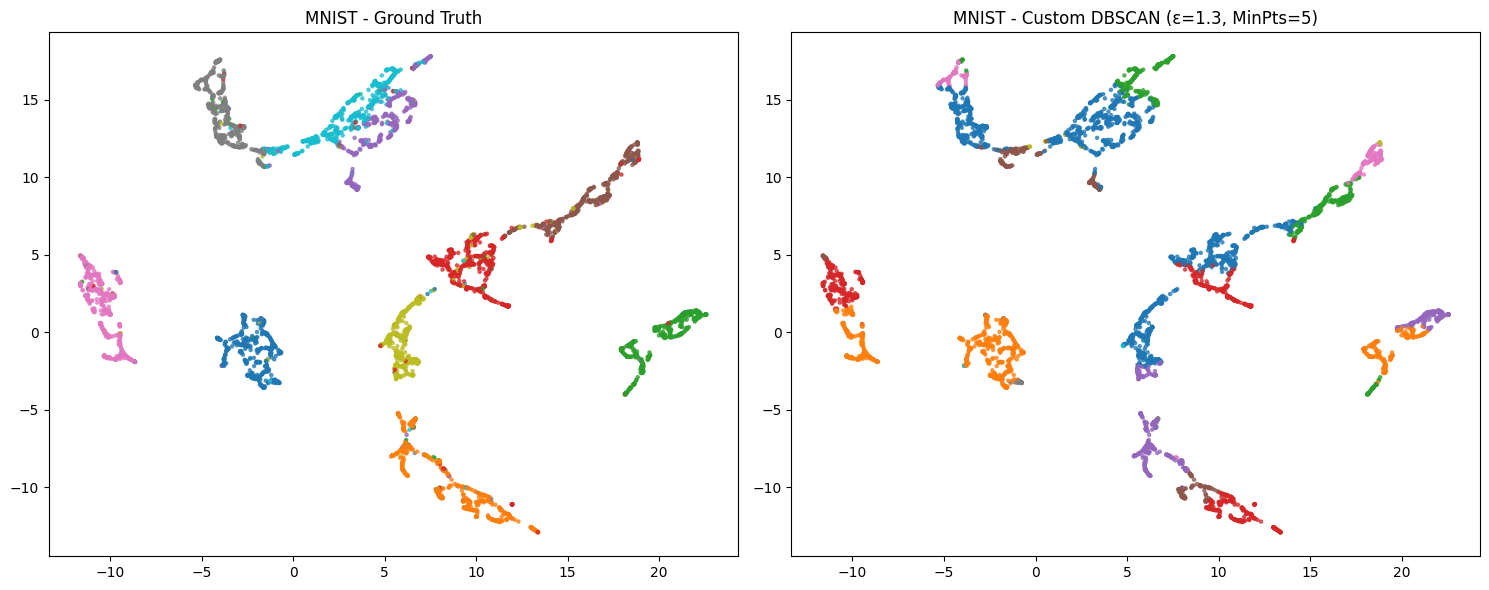

Loading Fashion MNIST dataset...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running Custom DBSCAN on FashionMNIST dataset with epsilon=3.4, min_pts=5

Evaluation for FashionMNIST dataset:
Number of clusters: 7
Number of noise points: 0 (0.00%)
Silhouette Score: 0.4487
Adjusted Rand Index: 0.4392
Normalized Mutual Information: 0.6429


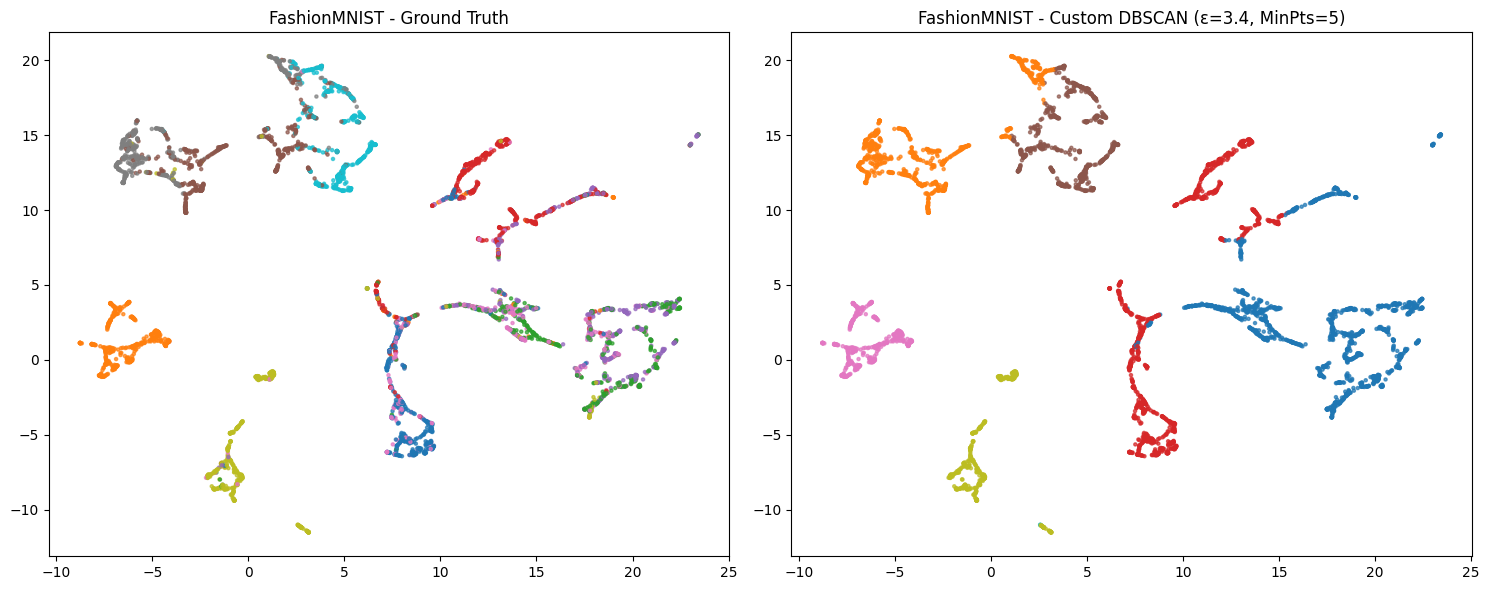

Loading Household Power Consumption dataset...


<ipython-input-4-8712d4e16d8e>:116: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running Custom DBSCAN on Household dataset with epsilon=0.8, min_pts=5

Evaluation for Household dataset:
Number of clusters: 181
Number of noise points: 333 (6.66%)
Silhouette Score: 0.0847
Adjusted Rand Index: 0.0302
Normalized Mutual Information: 0.1669


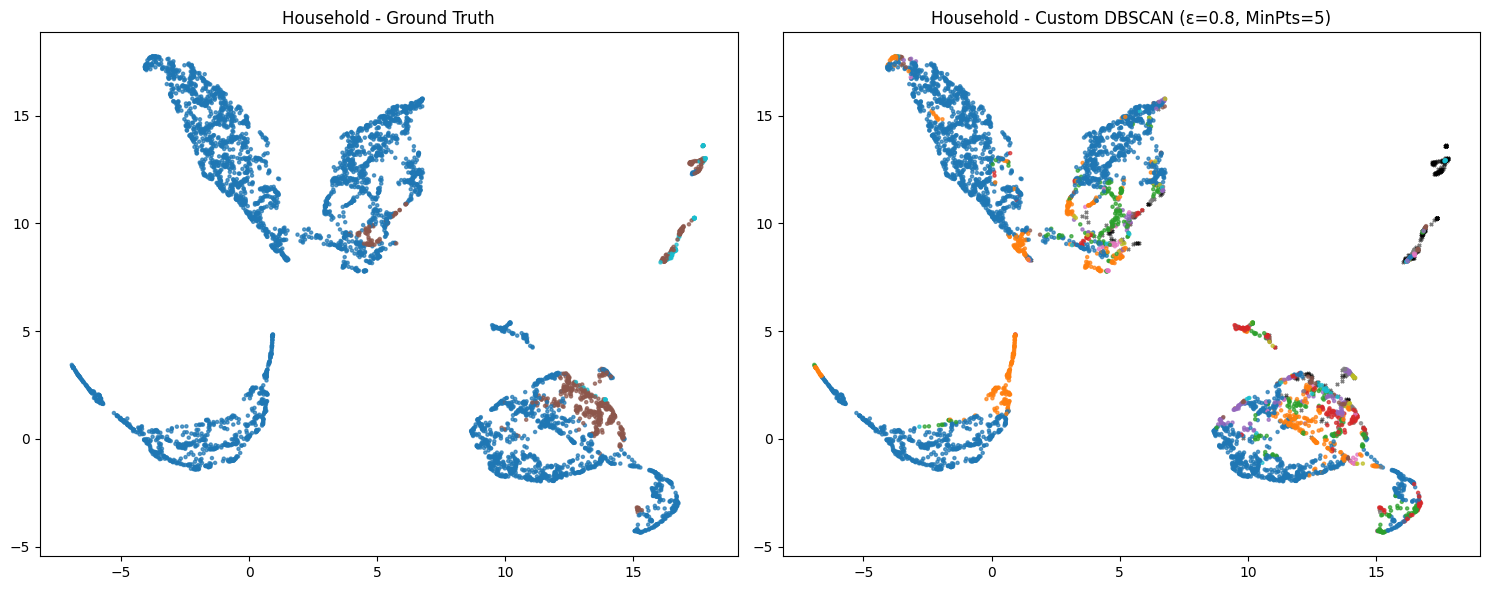

(array([ 1,  2,  3, ...,  1,  1, 60]),
 {'n_clusters': 181, 'n_noise': 333, 'noise_percentage': 6.660000000000001})

In [ ]:
# Set DBSCAN hyperparameters for each dataset (tuned roughly)
dbscan_params = {
    '20Newsgroups': {'epsilon': 3.7, 'min_pts': 5},
    'MNIST': {'epsilon': 1.3, 'min_pts': 5},
    'FashionMNIST': {'epsilon': 3.4, 'min_pts': 5},
    'Household': {'epsilon': 0.8, 'min_pts': 5},
}

# Process and run DBSCAN on 20 Newsgroups
X_20ng, y_20ng, X_umap_20ng = load_20newsgroups(n_samples=2000)
run_custom_dbscan_on_dataset(X_20ng, y_20ng, X_umap_20ng, '20Newsgroups',
                      epsilon=dbscan_params['20Newsgroups']['epsilon'],
                      min_pts=dbscan_params['20Newsgroups']['min_pts'])

# Process and run DBSCAN on MNIST
X_mnist, y_mnist, X_umap_mnist = load_mnist(n_samples=5000)
run_custom_dbscan_on_dataset(X_mnist, y_mnist, X_umap_mnist, 'MNIST',
                      epsilon=dbscan_params['MNIST']['epsilon'],
                      min_pts=dbscan_params['MNIST']['min_pts'])

# Process and run DBSCAN on Fashion MNIST
X_fmnist, y_fmnist, X_umap_fmnist = load_fashion_mnist(n_samples=5000)
run_custom_dbscan_on_dataset(X_fmnist, y_fmnist, X_umap_fmnist, 'FashionMNIST',
                      epsilon=dbscan_params['FashionMNIST']['epsilon'],
                      min_pts=dbscan_params['FashionMNIST']['min_pts'])

# Process and run DBSCAN on Household Power Consumption dataset
X_household, y_household, X_umap_household = load_household(n_samples=5000)
run_custom_dbscan_on_dataset(X_household, y_household, X_umap_household, 'Household',
                      epsilon=dbscan_params['Household']['epsilon'],
                      min_pts=dbscan_params['Household']['min_pts'])